# Definindo o problema

Conteúdo adicional para aprofundar os conhecimentos sobre Multi-Layer Perceptrons (MLP), incluindo conceitos teóricos complementares e exemplos práticos.

# Material Suplementar

Nesse material suplementar abordaremos 2 conceitos importantes, que devem ser utilizados em redes neurais:

- Learning Schedule
- Reprodutibilidade

## Learning Schedule

A ideia geral do Learning Rate Scheduling é tornar o parâmetro learning rate $n$ dinâmico ao longo do tempo $n_t$. Com isso tem-se normalmente que:

- LR alto no começo e LR baixo no final para melhorar a convergência

### Importando as Bibliotecas Necessárias

In [ ]:
import torch  # Uma das principais bibliotecas para construção e treinamento de modelos de Deep Learning. 
              # Oferece suporte para computação em GPU e diferenciação automática para cálculo de gradientes.
from torch.utils.data import DataLoader # DataLoader é uma classe do PyTorch que facilita o carregamento e a manipulação de conjuntos
                                        # de dados, permitindo a iteração eficiente sobre os dados durante o treinamento e avaliação de modelos.
from torchvision import datasets, transforms # torchvision é uma biblioteca complementar ao PyTorch, especializada em datasets, transformações e modelos pré-treinados para visão computacional.
import matplotlib.pyplot as plt # Principal biblioteca para criação de visualizações e gráficos em Python, essencial para analisar o comportamento do modelo e os dados.
torch.manual_seed(42) # Define uma semente para o gerador de números aleatórios do PyTorch, garantindo que os resultados sejam reproduzíveis em execuções subsequentes.

def try_gpu():
  """
  Função: try_gpu
  Descrição: Função responsável por executar a lógica de try_gpu dentro do contexto deste notebook, contribuindo para o processamento ou análise dos dados.
  """
  return torch.device('cuda' if torch.cuda.is_available() else 'cpu')

def accuracy(y_hat, y):
  """
  Função: accuracy
  Descrição: Função responsável por executar a lógica de accuracy dentro do contexto deste notebook, contribuindo para o processamento ou análise dos dados.
  """
  preds = y_hat.argmax(dim=1)
  return (preds == y).sum().item()

def evaluate_accuracy(model, data_iter, device):
  """
  Função: evaluate_accuracy
  Descrição: Função responsável por executar a lógica de evaluate_accuracy dentro do contexto deste notebook, contribuindo para o processamento ou análise dos dados.
  """
  model.eval()
  correct, total = 0, 0
  with torch.no_grad():
      for X, y in data_iter:
          X, y = X.to(device), y.to(device)
          y_hat = model(X)
          correct += (y_hat.argmax(dim=1) == y).sum().item()
          total += y.size(0)
  return correct / total

def load_data_fashion_mnist(batch_size):
  """
  Função: load_data_fashion_mnist
  Descrição: Função responsável por executar a lógica de load_data_fashion_mnist dentro do contexto deste notebook, contribuindo para o processamento ou análise dos dados.
  """
  transform = transforms.ToTensor()

  train_dataset = datasets.FashionMNIST(
      root='./data', train=True, download=True, transform=transform
  )
  test_dataset = datasets.FashionMNIST(
      root='./data', train=False, download=True, transform=transform
  )

  train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
  test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

  return train_loader, test_loader

In [ ]:
def train(model, train_iter, test_iter, num_epochs, loss_fn, optimizer, device, scheduler=None):
    """
    Função: train
    Descrição: Implementa o laço principal de treinamento, onde o modelo ajusta seus parâmetros iterativamente com base no erro calculado sobre os dados.
    """
    model.to(device)
    train_losses, train_accs, test_accs = [], [], []

    for epoch in range(num_epochs):
        model.train()
        total_loss, total_correct, total_samples = 0, 0, 0

        for X, y in train_iter:
            X, y = X.to(device), y.to(device)

            optimizer.zero_grad()
            y_hat = model(X)
            loss = loss_fn(y_hat, y)
            loss.backward()
            optimizer.step()

            total_loss += loss.item() * X.size(0)
            total_correct += (y_hat.argmax(dim=1) == y).sum().item()
            total_samples += X.size(0)

        train_loss = total_loss / total_samples
        train_acc = total_correct / total_samples
        test_acc = evaluate_accuracy(model, test_iter, device)

        train_losses.append(train_loss)
        train_accs.append(train_acc)
        test_accs.append(test_acc)

        if scheduler:
            try:
                for param_group in optimizer.param_groups:
                    param_group['lr'] = scheduler(epoch)
            except:
                scheduler.step()

        print(f"Epoch {epoch+1:02d} | loss {train_loss:.4f} | acc {train_acc:.4f} | test {test_acc:.4f}")

    plt.plot(train_losses, label="train loss")
    plt.plot(train_accs, label="train acc")
    plt.plot(test_accs, label="test acc")
    plt.xlabel("epoch")
    plt.legend()
    plt.show()

Epoch 01 | loss 0.6032 | acc 0.7694 | test 0.8503
Epoch 02 | loss 0.3637 | acc 0.8658 | test 0.8635
Epoch 03 | loss 0.3166 | acc 0.8842 | test 0.8785
Epoch 04 | loss 0.2908 | acc 0.8930 | test 0.8899
Epoch 05 | loss 0.2732 | acc 0.8987 | test 0.8802
Epoch 06 | loss 0.2672 | acc 0.8999 | test 0.8920
Epoch 07 | loss 0.2497 | acc 0.9067 | test 0.8926
Epoch 08 | loss 0.2425 | acc 0.9089 | test 0.8949
Epoch 09 | loss 0.2377 | acc 0.9121 | test 0.8914
Epoch 10 | loss 0.2304 | acc 0.9127 | test 0.8940


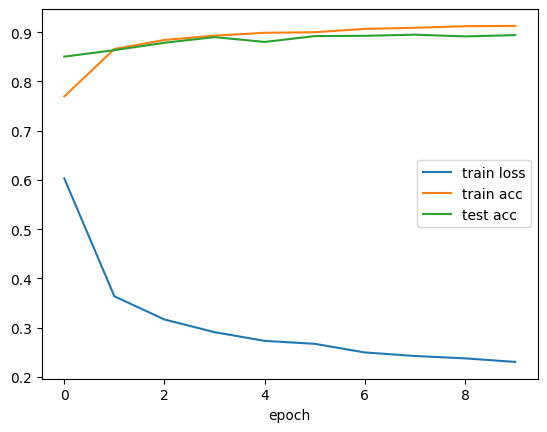

In [ ]:
import torch.nn as nn # nn é um módulo do PyTorch que fornece uma variedade de classes e funções para construir e treinar redes neurais, incluindo camadas, funções de ativação, e muito mais.
import torch.optim as optim # optim é um módulo do PyTorch que fornece várias classes de otimizadores para ajustar os parâmetros do modelo durante o treinamento.

device = try_gpu()
batch_size = 256

train_iter, test_iter = load_data_fashion_mnist(batch_size)

model = nn.Sequential(
    nn.Conv2d(1, 6, kernel_size=5, padding=2),
    nn.ReLU(),
    nn.MaxPool2d(2),
    nn.Conv2d(6, 16, kernel_size=5),
    nn.ReLU(),
    nn.MaxPool2d(2),
    nn.Flatten(),
    nn.Linear(16 * 5 * 5, 120),
    nn.ReLU(),
    nn.Linear(120, 84),
    nn.ReLU(),
    nn.Linear(84, 10)
)

loss_fn = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)
train(model, train_iter, test_iter, 10, loss_fn, optimizer, device, None)

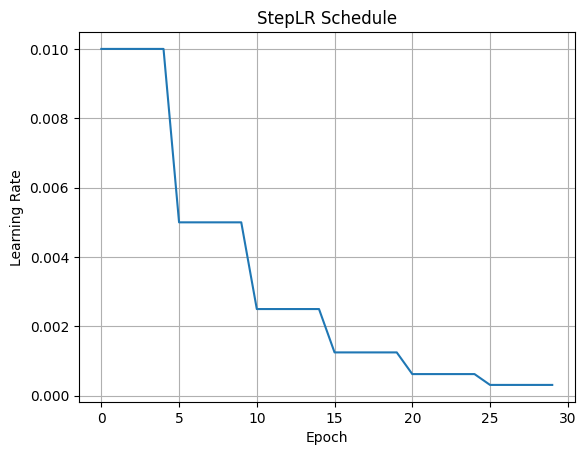

In [ ]:
## Vamos testar 2 learning schedule diferentes o primeiro mais simples StepLR
# O que ele é faz é simples a cada step_size multiplica o learning rate por gamma
model_test = torch.nn.Linear(1, 1)
optimizer = torch.optim.Adam(model_test.parameters(), lr=0.01)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)


lrs = []
epochs = 30

for epoch in range(epochs):
    lrs.append(optimizer.param_groups[0]['lr'])
    optimizer.step()
    scheduler.step()

plt.plot(range(epochs), lrs)
plt.xlabel("Epoch")
plt.ylabel("Learning Rate")
plt.title("StepLR Schedule")
plt.grid()
plt.show()

/tmp/ipykernel_2407/2532554557.py:35: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  scheduler.step()


Epoch 01 | loss 0.6467 | acc 0.7505 | test 0.8467
Epoch 02 | loss 0.3618 | acc 0.8672 | test 0.8706
Epoch 03 | loss 0.3176 | acc 0.8827 | test 0.8785
Epoch 04 | loss 0.2961 | acc 0.8897 | test 0.8845
Epoch 05 | loss 0.2841 | acc 0.8936 | test 0.8809
Epoch 06 | loss 0.2667 | acc 0.9002 | test 0.8899
Epoch 07 | loss 0.2600 | acc 0.9026 | test 0.8870
Epoch 08 | loss 0.2498 | acc 0.9064 | test 0.8892
Epoch 09 | loss 0.2471 | acc 0.9074 | test 0.8905
Epoch 10 | loss 0.2411 | acc 0.9093 | test 0.8918


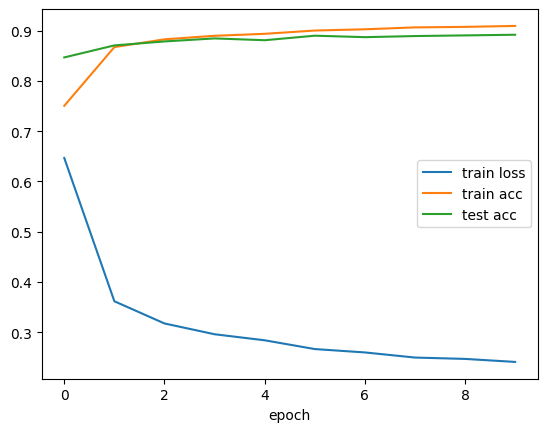

In [ ]:
# Definindo modelo
model = nn.Sequential(
    nn.Conv2d(1, 6, kernel_size=5, padding=2),
    nn.ReLU(),
    nn.MaxPool2d(2),
    nn.Conv2d(6, 16, kernel_size=5),
    nn.ReLU(),
    nn.MaxPool2d(2),
    nn.Flatten(),
    nn.Linear(16 * 5 * 5, 120),
    nn.ReLU(),
    nn.Linear(120, 84),
    nn.ReLU(),
    nn.Linear(84, 10)
)

scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)
loss_fn = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)
train(model, train_iter, test_iter, 10, loss_fn, optimizer, device, scheduler)

Vamos testar usar agora um scheduler mais avançado conhecido como Cosine Annealing, que faz:

$$
    n_{t+1} = n_{min} + (n_t - n_{min}) . \frac{1 + cos(\frac{(T_{cur}+1)+\pi}{T_{max}})}{1 + cos(\frac{T_{cur}\pi}{T_{max}})}
$$

- $T_{max}$ é o máximo número de épocas por ciclo
- $T_{cur}$ é o número de épocas desde o último restart
- $n_{min}$ é definido (default = 0)

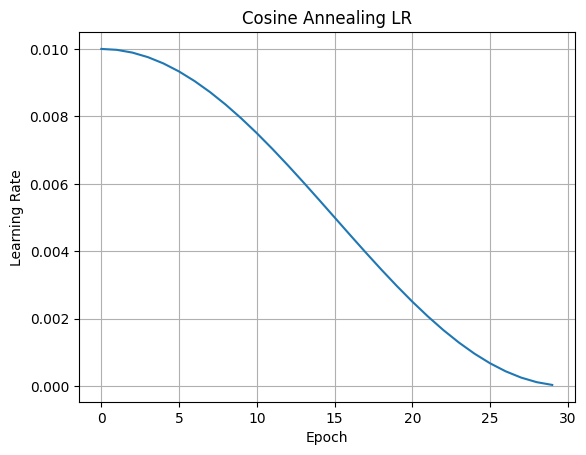

In [ ]:
## Vamos testar usar agora um scheduler mais avançado conhecido como
# Cosine Annealing
model_test = torch.nn.Linear(1, 1)
optimizer = torch.optim.Adam(model_test.parameters(), lr=0.01)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs, eta_min=1e-5)

lrs = []
epochs = 30

for epoch in range(epochs):
    lrs.append(optimizer.param_groups[0]['lr'])
    optimizer.step()
    scheduler.step()

plt.plot(range(epochs), lrs)
plt.xlabel("Epoch")
plt.ylabel("Learning Rate")
plt.title("Cosine Annealing LR")
plt.grid()
plt.show()

Epoch 01 | loss 0.6166 | acc 0.7629 | test 0.8438
Epoch 02 | loss 0.3464 | acc 0.8715 | test 0.8614
Epoch 03 | loss 0.3074 | acc 0.8862 | test 0.8754
Epoch 04 | loss 0.2846 | acc 0.8938 | test 0.8841
Epoch 05 | loss 0.2664 | acc 0.9015 | test 0.8899
Epoch 06 | loss 0.2576 | acc 0.9045 | test 0.8948
Epoch 07 | loss 0.2551 | acc 0.9049 | test 0.8949
Epoch 08 | loss 0.2436 | acc 0.9093 | test 0.8923
Epoch 09 | loss 0.2368 | acc 0.9122 | test 0.8922
Epoch 10 | loss 0.2312 | acc 0.9137 | test 0.8893


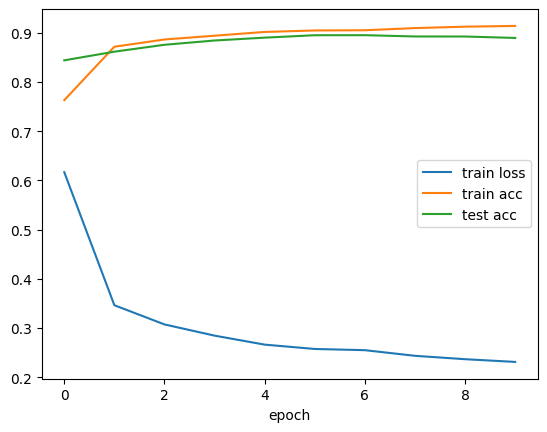

In [ ]:
# Definindo variável ou realizando operação: model
model = nn.Sequential(
    nn.Conv2d(1, 6, kernel_size=5, padding=2),
    nn.ReLU(),
    nn.MaxPool2d(2),
    nn.Conv2d(6, 16, kernel_size=5),
    nn.ReLU(),
    nn.MaxPool2d(2),
    nn.Flatten(),
    nn.Linear(16 * 5 * 5, 120),
    nn.ReLU(),
    nn.Linear(120, 84),
    nn.ReLU(),
    nn.Linear(84, 10)
)

scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)
loss_fn = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)
train(model, train_iter, test_iter, 10, loss_fn, optimizer, device, scheduler)